Step 0/2500
Step 100/2500
Step 200/2500
Step 300/2500
Step 400/2500
Step 500/2500
Step 600/2500
Step 700/2500
Step 800/2500
Step 900/2500
Step 1000/2500
Step 1100/2500
Step 1200/2500
Step 1300/2500
Step 1400/2500
Step 1500/2500
Step 1600/2500
Step 1700/2500
Step 1800/2500
Step 1900/2500
Step 2000/2500
Step 2100/2500
Step 2200/2500
Step 2300/2500
Step 2400/2500


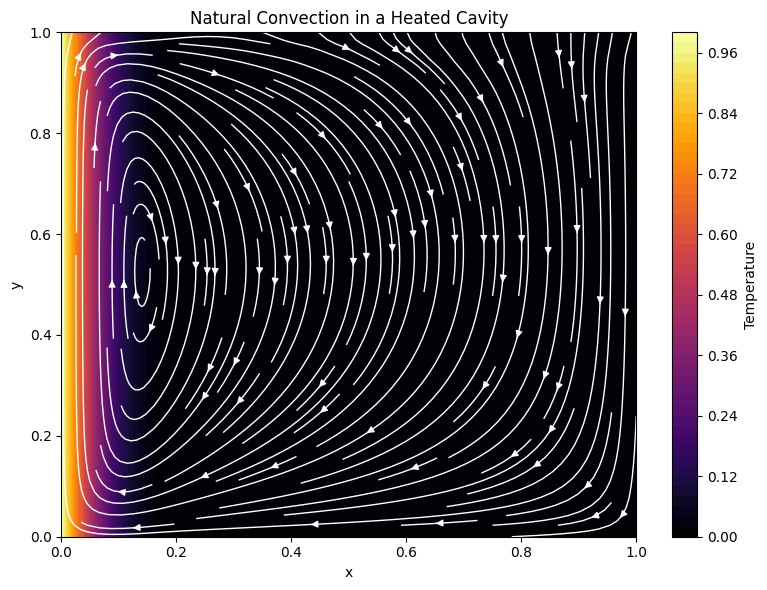

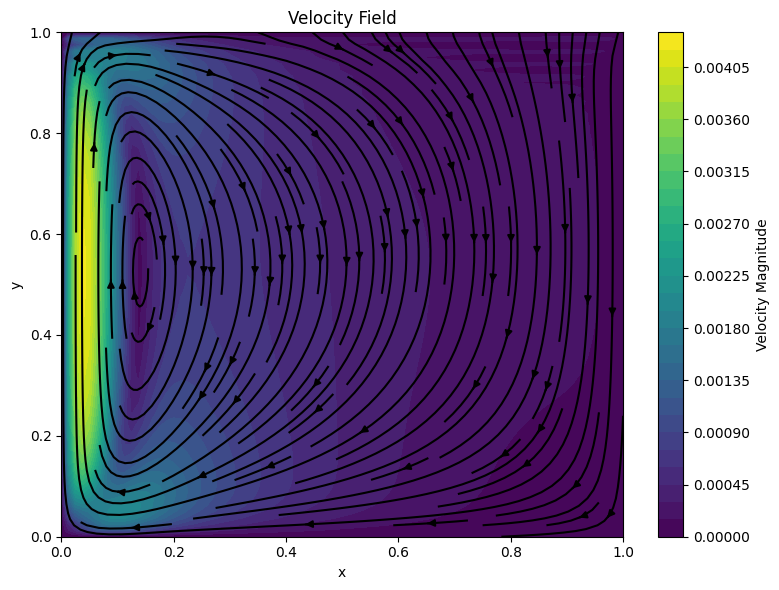

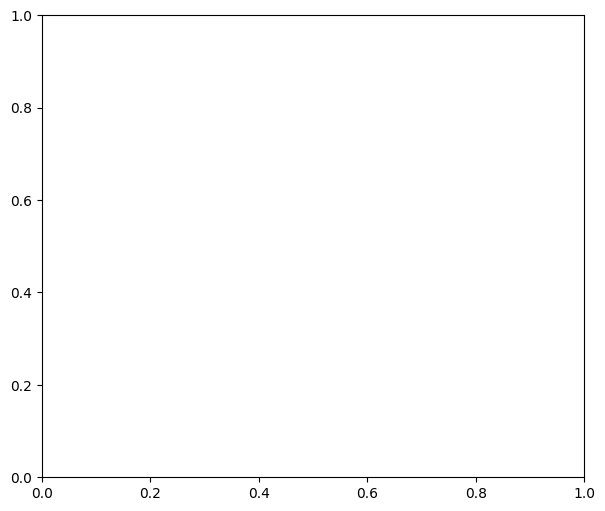

In [1]:
# ==============================================================
# Natural Convection in a Heated Cavity
# ==============================================================
#
# Author: OpenAI ChatGPT
#
# Description:
# ------------
# This notebook simulates 2D natural convection inside a square
# cavity using the incompressible Navier-Stokes equations coupled
# with the temperature transport equation under the Boussinesq
# approximation.
#
# Physics:
# --------
# - Left wall  : hot temperature
# - Right wall : cold temperature
# - Top/bottom : adiabatic
#
# A buoyancy force appears due to temperature differences,
# generating circulation inside the cavity.
#
# Numerical Method:
# -----------------
# - Finite differences
# - Explicit time integration
# - Projection method for incompressibility
#
# ==============================================================
# IMPORTS
# ==============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ==============================================================
# DOMAIN PARAMETERS
# ==============================================================

Nx = 81
Ny = 81

Lx = 1.0
Ly = 1.0

dx = Lx / (Nx - 1)
dy = Ly / (Ny - 1)

x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)

X, Y = np.meshgrid(x, y)

# ==============================================================
# PHYSICAL PARAMETERS
# ==============================================================

rho = 1.0          # density
nu = 1e-3          # kinematic viscosity
alpha = 1e-3       # thermal diffusivity

beta = 1e-3        # thermal expansion coefficient
g = 9.81           # gravity

Thot = 1.0
Tcold = 0.0

# ==============================================================
# TIME PARAMETERS
# ==============================================================

dt = 0.001
nt = 2500
nit = 50

# ==============================================================
# FIELD VARIABLES
# ==============================================================

u = np.zeros((Ny, Nx))   # x-velocity
v = np.zeros((Ny, Nx))   # y-velocity

p = np.zeros((Ny, Nx))   # pressure

T = np.zeros((Ny, Nx))   # temperature

# Initial temperature field
T[:, 0] = Thot
T[:, -1] = Tcold

# ==============================================================
# PRESSURE POISSON SOLVER
# ==============================================================

def pressure_poisson(p, dx, dy, b):

    pn = np.empty_like(p)

    for q in range(nit):

        pn[:] = p[:]

        p[1:-1,1:-1] = (
            (
                (pn[1:-1,2:] + pn[1:-1,:-2]) * dy**2
                +
                (pn[2:,1:-1] + pn[:-2,1:-1]) * dx**2
            )
            /
            (2 * (dx**2 + dy**2))
            -
            dx**2 * dy**2
            /
            (2 * (dx**2 + dy**2))
            *
            b[1:-1,1:-1]
        )

        # Pressure boundary conditions
        p[:, -1] = p[:, -2]
        p[:,  0] = p[:,  1]
        p[0, :]  = p[1, :]
        p[-1,:]  = 0.0

    return p

# ==============================================================
# BUILD RHS OF PRESSURE EQUATION
# ==============================================================

def build_b(rho, dt, u, v, dx, dy):

    b = np.zeros_like(u)

    b[1:-1,1:-1] = rho * (
        (
            1/dt *
            (
                (u[1:-1,2:] - u[1:-1,:-2]) / (2*dx)
                +
                (v[2:,1:-1] - v[:-2,1:-1]) / (2*dy)
            )
        )
        -
        (
            ((u[1:-1,2:] - u[1:-1,:-2]) / (2*dx))**2
        )
        -
        2 * (
            ((u[2:,1:-1] - u[:-2,1:-1]) / (2*dy))
            *
            ((v[1:-1,2:] - v[1:-1,:-2]) / (2*dx))
        )
        -
        (
            ((v[2:,1:-1] - v[:-2,1:-1]) / (2*dy))**2
        )
    )

    return b

# ==============================================================
# STORAGE FOR VISUALIZATION
# ==============================================================

save_interval = 50

T_history = []
u_history = []
v_history = []

# ==============================================================
# MAIN TIME LOOP
# ==============================================================

for n in range(nt):

    un = u.copy()
    vn = v.copy()
    Tn = T.copy()

    # ----------------------------------------------------------
    # Pressure RHS
    # ----------------------------------------------------------

    b = build_b(rho, dt, un, vn, dx, dy)

    # ----------------------------------------------------------
    # Pressure solution
    # ----------------------------------------------------------

    p = pressure_poisson(p, dx, dy, b)

    # ----------------------------------------------------------
    # Velocity equations
    # ----------------------------------------------------------

    u[1:-1,1:-1] = (
        un[1:-1,1:-1]
        -
        un[1:-1,1:-1] * dt/dx *
        (un[1:-1,1:-1] - un[1:-1,:-2])
        -
        vn[1:-1,1:-1] * dt/dy *
        (un[1:-1,1:-1] - un[:-2,1:-1])
        -
        dt/(2*rho*dx) *
        (p[1:-1,2:] - p[1:-1,:-2])
        +
        nu * (
            dt/dx**2 *
            (un[1:-1,2:] - 2*un[1:-1,1:-1] + un[1:-1,:-2])
            +
            dt/dy**2 *
            (un[2:,1:-1] - 2*un[1:-1,1:-1] + un[:-2,1:-1])
        )
    )

    # Buoyancy term included in v equation
    buoyancy = beta * g * (Tn[1:-1,1:-1] - Tcold)

    v[1:-1,1:-1] = (
        vn[1:-1,1:-1]
        -
        un[1:-1,1:-1] * dt/dx *
        (vn[1:-1,1:-1] - vn[1:-1,:-2])
        -
        vn[1:-1,1:-1] * dt/dy *
        (vn[1:-1,1:-1] - vn[:-2,1:-1])
        -
        dt/(2*rho*dy) *
        (p[2:,1:-1] - p[:-2,1:-1])
        +
        nu * (
            dt/dx**2 *
            (vn[1:-1,2:] - 2*vn[1:-1,1:-1] + vn[1:-1,:-2])
            +
            dt/dy**2 *
            (vn[2:,1:-1] - 2*vn[1:-1,1:-1] + vn[:-2,1:-1])
        )
        +
        dt * buoyancy
    )

    # ----------------------------------------------------------
    # Temperature transport equation
    # ----------------------------------------------------------

    T[1:-1,1:-1] = (
        Tn[1:-1,1:-1]
        -
        un[1:-1,1:-1] * dt/dx *
        (Tn[1:-1,1:-1] - Tn[1:-1,:-2])
        -
        vn[1:-1,1:-1] * dt/dy *
        (Tn[1:-1,1:-1] - Tn[:-2,1:-1])
        +
        alpha * (
            dt/dx**2 *
            (Tn[1:-1,2:] - 2*Tn[1:-1,1:-1] + Tn[1:-1,:-2])
            +
            dt/dy**2 *
            (Tn[2:,1:-1] - 2*Tn[1:-1,1:-1] + Tn[:-2,1:-1])
        )
    )

    # ----------------------------------------------------------
    # Velocity boundary conditions (no-slip)
    # ----------------------------------------------------------

    u[0, :] = 0
    u[-1,:] = 0
    u[:, 0] = 0
    u[:, -1] = 0

    v[0, :] = 0
    v[-1,:] = 0
    v[:, 0] = 0
    v[:, -1] = 0

    # ----------------------------------------------------------
    # Temperature boundary conditions
    # ----------------------------------------------------------

    # Left wall hot
    T[:, 0] = Thot

    # Right wall cold
    T[:, -1] = Tcold

    # Top/bottom adiabatic
    T[0, :] = T[1, :]
    T[-1,:] = T[-2,:]

    # ----------------------------------------------------------
    # Save frames
    # ----------------------------------------------------------

    if n % save_interval == 0:
        T_history.append(T.copy())
        u_history.append(u.copy())
        v_history.append(v.copy())

    # ----------------------------------------------------------
    # Progress
    # ----------------------------------------------------------

    if n % 100 == 0:
        print(f"Step {n}/{nt}")

# ==============================================================
# FINAL TEMPERATURE FIELD
# ==============================================================

plt.figure(figsize=(8,6))

cont = plt.contourf(X, Y, T, 50, cmap='inferno')
plt.colorbar(cont, label='Temperature')

plt.streamplot(
    X,
    Y,
    u,
    v,
    color='white',
    density=1.5,
    linewidth=1
)

plt.xlabel('x')
plt.ylabel('y')

plt.title('Natural Convection in a Heated Cavity')

plt.tight_layout()
plt.show()

# ==============================================================
# VELOCITY MAGNITUDE
# ==============================================================

velocity = np.sqrt(u**2 + v**2)

plt.figure(figsize=(8,6))

cont = plt.contourf(X, Y, velocity, 40, cmap='viridis')
plt.colorbar(cont, label='Velocity Magnitude')

plt.streamplot(
    X,
    Y,
    u,
    v,
    color='black',
    density=1.5
)

plt.xlabel('x')
plt.ylabel('y')

plt.title('Velocity Field')

plt.tight_layout()
plt.show()

# ==============================================================
# ANIMATION
# ==============================================================

fig, ax = plt.subplots(figsize=(7,6))

def animate(i):

    ax.clear()

    Tframe = T_history[i]
    uframe = u_history[i]
    vframe = v_history[i]

    cont = ax.contourf(
        X,
        Y,
        Tframe,
        50,
        cmap='inferno'
    )

    ax.streamplot(
        X,
        Y,
        uframe,
        vframe,
        color='white',
        density=1.5
    )

    ax.set_title(f'Natural Convection - Frame {i}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

    return cont

anim = FuncAnimation(
    fig,
    animate,
    frames=len(T_history),
    interval=80
)

plt.show()

# ==============================================================
# END
# ==============================================================